____
# Nadir distance dependency


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
    plot_error,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
dt = 12
alti_product_key = "swot2km"
drifter_preprocess = ""
drifter_preprocess_param = ""
from diagnosis import define_coloc_source

colocs_sources = define_coloc_source(
    "12h", drifter_preprocess, drifter_preprocess_param
)

_______
# Compute and project (x = cross, y = alg)

In [3]:
# SURFACE
base_dic = dict(
    dt="12h",
    drifter_preprocess=drifter_preprocess,
    drifter_preprocess_param=drifter_preprocess_param,
    alti_product_key=alti_product_key,
    alti_diff_method="xarray_diff",
    alti_diff_method_param="",
    ggd_var="etac",
    wd_product_key="era5",
    wd_model="rio",
    wd_depth="0",
)


comb_list = [base_dic]
l = [
    "L3-2km",
]
ds0 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds0["comb"] = ds0["id_comb"]
ds0["id_comb"] = ("id_comb", l)
distance_to_coast = ds0.distance_to_coast.isel(id_comb=0)
ds0["distance_to_coast"] = ("row_number", distance_to_coast.values)

# DEPTH 15M
base_dic = update_dict(base_dic, dict(wd_depth="15"))
comb_list = [base_dic]

ds15 = dataset_coloc_combs(comb_list, nearest=False, remove_id_outliers=True)
ds15["comb"] = ds15["id_comb"]
ds15["id_comb"] = ("id_comb", l)
distance_to_coast = ds15.distance_to_coast.isel(id_comb=0)
ds15["distance_to_coast"] = ("row_number", distance_to_coast.values)

DS = xr.concat(
    [ds0.where(ds0.depth == 0, drop=True), ds15.where(ds15.depth == 15, drop=True)],
    dim="row_number",
)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < dt).dropna("row_number")
DS = DS.where((DS.ggde < 1.5e-4) & (DS.ggdn < 1.5e-4), drop=True)
DS = DS.where(DS.distance_to_coast > 10e3, drop=True)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mdemol/DATA_MED_COLOC/coloc_files/drifters/drifterscoloc_12h_spectral_decomp_all_med_variational_10min_v0.csv'

In [ ]:
# rotate
def rotate(e, n, phi):
    return np.cos(phi) * e - np.sin(phi) * n, np.sin(phi) * e + np.cos(phi) * n


def crossalg_proj(dsen):
    ds = dsen.copy()
    ds["sumx"], ds["sumy"] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[["sumx", "sumy"]]
    var = ["acc", "cor", "ggd", "wd", "sum"]
    prod = [l for l in ds.keys() if "prodn" in l]
    exc = [l for l in ds.keys() if "excn" in l]
    for v in var:
        dsxy[v + "x"], dsxy[v + "y"] = rotate(dsen[v + "e"], dsen[v + "n"], dsen.phi)

    for direction in ["x", "y"]:
        if direction == "x":
            l = {"acc": "accx", "cor": "corx", "ggd": "ggdx", "wd": "wdx"}
        if direction == "y":
            l = {"acc": "accy", "cor": "cory", "ggd": "ggdy", "wd": "wdy"}

        # sum
        dsxy["sum" + direction] = sum([dsxy[l[v]] for v in l])

        # simple var + sum- one term
        for v in l:
            dsxy[l[v]] = dsxy[l[v]]
            dsxy["exc" + direction + "_" + v] = dsxy["sum" + direction] - dsxy[l[v]]

        # 2 by 2 product
        import itertools

        couple = list(itertools.combinations(list(l.keys()), 2))
        for c in couple:
            dsxy["prod" + direction + "_" + "_".join(c)] = (
                dsxy[c[0] + direction] * dsxy[c[1] + direction]
            )
    return dsxy


DSr = crossalg_proj(DS)

In [5]:
dfr = DSr.to_dataframe().reset_index().set_index("row_number")
dfs = pd.read_csv(
    os.path.join(
        zarr_dir,
        "coloc_files",
        "alti",
        f"alticoloc_{alti_product_key}_general_" + colocs_sources + ".csv",
    )
).set_index("row_number")
dfs["abs_cross_track_distance"] = abs(dfs["cross_track_distance"])

dfrr = pd.concat(
    [dfs[["swh_model", "abs_cross_track_distance", "ssh_karin_uncert"]], dfr], axis=1
).dropna()

_________
# Dependency on the cross_track distance

In [6]:
compute_error = "centrallimit"
dfct = dfrr[dfrr.swh_model < 2]
ct_dist_bins = np.arange(0, 70000, 1000)
dfct["abs_cross_track_distance_cut"] = pd.cut(
    dfct["abs_cross_track_distance"],
    ct_dist_bins,
    labels=(ct_dist_bins[1:] + ct_dist_bins[:-1]) / 2,
)
dsc = compute_mean_square_groupby(
    dfct,
    groupby="abs_cross_track_distance_cut",
    dirname=("x", "y"),
    compute_error=compute_error,
    vars_errors=["Ex_ggd", "Ey_ggd"],
)
dsc["meanbin_swh_model"] = (
    dfct.groupby("abs_cross_track_distance_cut", observed=False)
    .swh_model.mean()
    .dropna()
    .to_xarray()
)
dsc = dsc.where(dsc.nb_coloc > 100)
dsc["abs_cross_track_distance_cut"] = dsc["abs_cross_track_distance_cut"] / 1000

/dev/shm/pbs.2770549.datarmor0/ipykernel_5646/2810217899.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfct['abs_cross_track_distance_cut'] = pd.cut(dfct['abs_cross_track_distance'], ct_dist_bins, labels=(ct_dist_bins[1:] + ct_dist_bins[:-1])/2)


[ 2.89120845e-03 -1.58834110e-01  5.39586566e+00]


(8.0, 62.0)

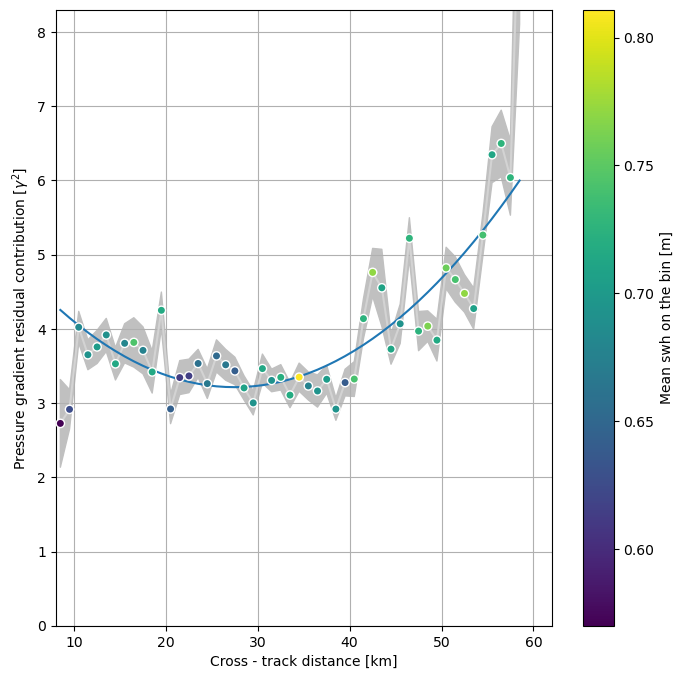

In [7]:
dsc = dsc.dropna("abs_cross_track_distance_cut")

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsc["E_ggd"] = dsc.Ex_ggd + dsc.Ey_ggd
dsc["ser__E_ggd"] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
# dsc.Ex_ggd.plot(ax=ax, marker='+')
# dsc.Ey_ggd.plot(ax=ax, marker='+')
dsc.E_ggd.plot(ax=ax, marker="+", c="lightgrey")
plot_error(dsc, "abs_cross_track_distance_cut", "E_ggd", ax=ax, suf="ser__")
sc = dsc.plot.scatter(
    x="abs_cross_track_distance_cut", y="E_ggd", c=dsc.meanbin_swh_model, zorder=10
)
plt.colorbar(sc, label="Mean swh on the bin [m]")

c = dsc.abs_cross_track_distance_cut
coef = np.polyfit(c, dsc.E_ggd, 2, w=dsc.nb_coloc)
ax.plot(c, coef[0] * c**2 + coef[1] * c + coef[2])
print(coef)

ax.grid()
ax.set_ylabel(r"Pressure gradient residual contribution [$\gamma^2$]")
ax.set_xlabel(r"Cross - track distance [km]")

ax.set_ylim(0, 8.3)
ax.set_xlim(8, 62)

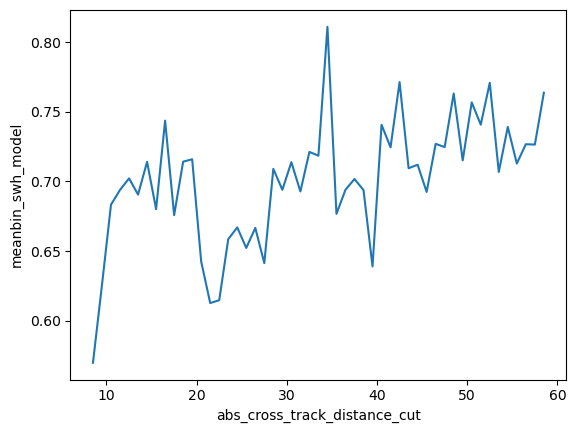

In [8]:
dsc.meanbin_swh_model.plot()

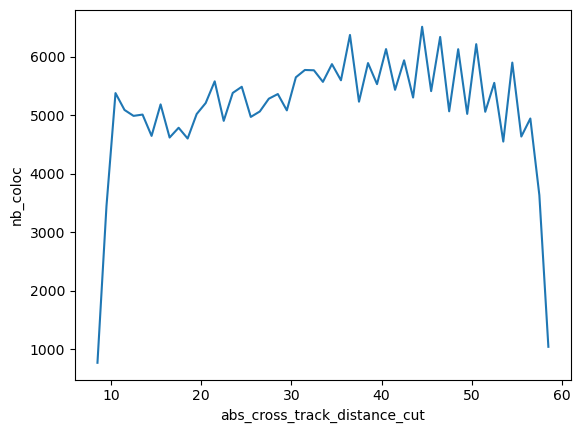

In [9]:
dsc.nb_coloc.plot()

Text(0.5, 0, 'Cross - track distance [km]')

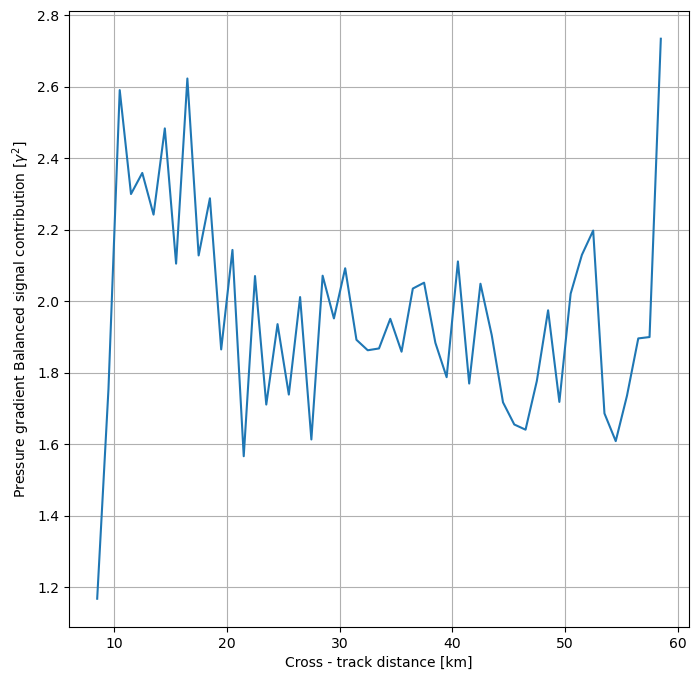

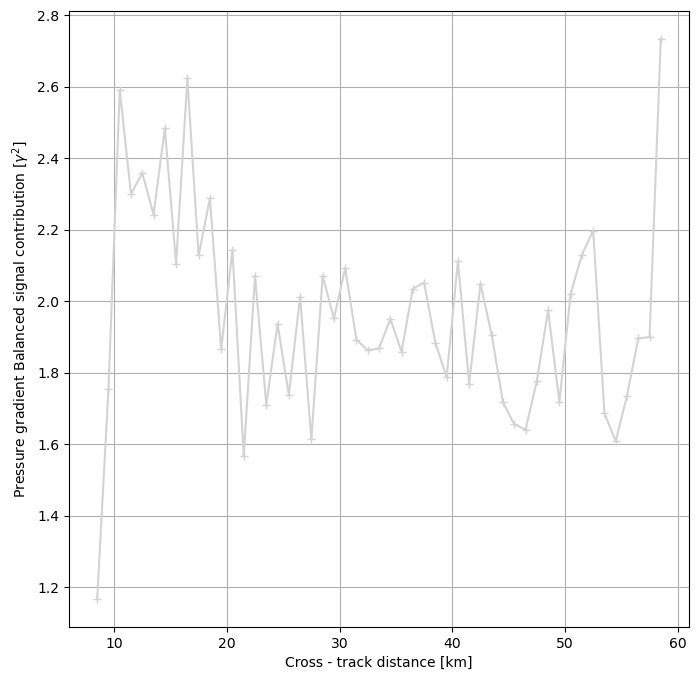

In [10]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
(dsc.Bx_ggd + dsc.By_ggd).plot(ax=ax)
ax.grid()
ax.set_ylabel(r"Pressure gradient Balanced signal contribution [$\gamma^2$]")
ax.set_xlabel(r"Cross - track distance [km]")

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
dsc["B_ggd"] = dsc.Bx_ggd + dsc.By_ggd

dsc.B_ggd.plot(ax=ax, marker="+", c="lightgrey")


ax.grid()
ax.set_ylabel(r"Pressure gradient Balanced signal contribution [$\gamma^2$]")
ax.set_xlabel(r"Cross - track distance [km]")

In [11]:
dss = dfrr.to_xarray()
plot_join_pdfs(dss, "swh_model", "abs_cross_track_distance", binx=100, biny=100)

NameError: name 'plot_join_pdfs' is not defined

In [ ]:
compute_error = "centrallimit"
dfb = dfrr.copy()
# Cross_track distance
ct_dist_bins = np.arange(0, 70000, 2000)
dfb["abs_cross_track_distance_cut"] = pd.cut(
    dfb["abs_cross_track_distance"],
    ct_dist_bins,
    labels=(ct_dist_bins[1:] + ct_dist_bins[:-1]) / 2,
)
# SWH
swh_dist_bins = np.array([0, 1, 2])
dfb["swh_model_cut"] = pd.cut(
    dfb["swh_model"], swh_dist_bins, labels=(swh_dist_bins[1:] + swh_dist_bins[:-1]) / 2
)

# Binned diag
dsc = compute_mean_square_groupby(
    dfb,
    groupby=["abs_cross_track_distance_cut", "swh_model_cut"],
    dirname=("x", "y"),
    compute_error=compute_error,
    vars_errors=["Ex_ggd", "Ey_ggd"],
)


# dsc['meanbin_swh_model'] = dfct.groupby('abs_cross_track_distance_cut', observed=False).swh_model.mean().dropna().to_xarray()
dsc = dsc.where(dsc.nb_coloc > 100)
dsc["abs_cross_track_distance_cut"] = dsc["abs_cross_track_distance_cut"] / 1000

In [63]:
dsc

<xarray.Dataset> Size: 73kB
Dimensions:                       (abs_cross_track_distance_cut: 34,
                                   swh_model_cut: 2)
Coordinates:
  * abs_cross_track_distance_cut  (abs_cross_track_distance_cut) float64 272B ...
  * swh_model_cut                 (swh_model_cut) float64 16B 0.5 1.5
Data variables: (12/133)
    ACCx                          (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    CORx                          (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    GGDx                          (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    WDx                           (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    Sx                            (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    sigmax                        (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ...                            ...
    ser__X_acc_wd                 (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ser__X_cor_ggd                (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ser__X_cor_wd                 (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ser__X_ggd_wd                 (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ser__D_cyclo                  (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...
    ser__D_anticyclo              (abs_cross_track_distance_cut, swh_model_cut) float64 544B ...

[ 4.71022176e-04 -3.57315960e-02  1.60807920e+00]
[ 1.03905271e-03 -8.95372491e-02  2.74277135e+00]


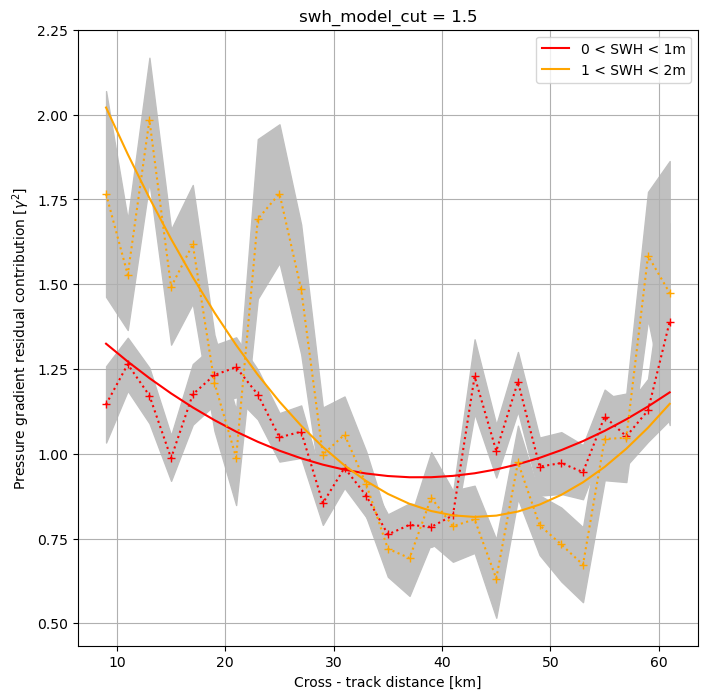

In [64]:
dsc = dsc.dropna('abs_cross_track_distance_cut')

plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8,8), frameon=False)
dsc['E_ggd'] = dsc.Ex_ggd + dsc.Ey_ggd
dsc['ser__E_ggd'] = dsc.ser__Ex_ggd + dsc.ser__Ey_ggd
#dsc.Ex_ggd.plot(ax=ax, marker='+')
#dsc.Ey_ggd.plot(ax=ax, marker='+')
color = ['r', 'orange', 'g']
for i in range(len(swh_dist_bins)-1):
    dsc.isel(swh_model_cut=i).E_ggd.plot(ax=ax, marker='+', c=color[i], ls=':')
    plot_error(dsc.isel(swh_model_cut=i), 'abs_cross_track_distance_cut', 'E_ggd', ax=ax, suf='ser__')
#sc = dsc.plot.scatter(x = 'abs_cross_track_distance_cut', y='E_ggd', c=dsc.meanbin_swh_model,zorder=10)
#plt.colorbar(sc, label ='Mean swh on the bin [m]')
    c = dsc.isel(swh_model_cut=i).abs_cross_track_distance_cut
    coef = np.polyfit(c, dsc.isel(swh_model_cut=i).E_ggd,2,w =dsc.isel(swh_model_cut=i).nb_coloc)
    ax.plot(c, coef[0]*c**2  +coef[1]*c + coef[2], color = color[i], label = f'{swh_dist_bins[i]} < SWH < {swh_dist_bins[i+1]}m')
    print(coef)

ax.grid()
ax.set_ylabel(r'Pressure gradient residual contribution [$\gamma^2$]')
ax.set_xlabel(r'Cross - track distance [km]')

#ax.set_ylim(0, 3)
#ax.set_xlim(8,62)
ax.legend()
ax.set_title(')

________
# Distance_to_coast

In [40]:
compute_error = "bootstrap"

dfdtc = dfrr.copy()
dtc_bins = np.linspace(0, 200e3, 100)
dfdtc["dtc_cut"] = pd.cut(
    dfdtc["distance_to_coast"], dtc_bins, labels=(dtc_bins[1:] + dtc_bins[:-1]) / 2
)
dsdtc = compute_mean_square_groupby(
    dfdtc,
    groupby="dtc_cut",
    dirname=("x", "y"),
    compute_error=compute_error,
    vars_errors=["Ex_ggd", "Ey_ggd"],
)
dsdtc = dsdtc.where(dsdtc.nb_coloc > 0).dropna("dtc_cut")

/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ex_ggd


/Users/mdemol/code/med_analysis/diagnosis.py:373: UserWarning: `meta` is not specified, inferred from partial data. Please provide `meta` if the result is unexpected.
  Before: .apply(func)
  After:  .apply(func, meta={'x': 'f8', 'y': 'f8'}) for dataframe result
  or:     .apply(func, meta=('x', 'f8'))            for series result
  .apply(compute_bootstrap_error)


Ey_ggd


Text(0.5, 0, 'Distance to coast [m]')

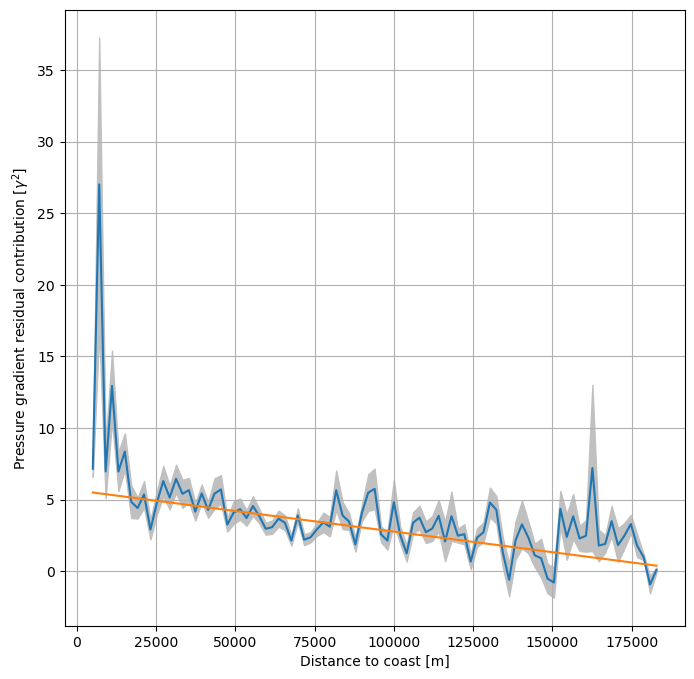

In [49]:
plt.rcParams["axes.edgecolor"] = "k"
fig, ax = plt.subplots(1, 1, figsize=(8, 8), frameon=False)
# dsdtc.Ex_ggd.plot(ax=ax, label='x')
# dsdtc.Ey_ggd.plot(ax=ax, label='y')
dsdtc.E_ggd.plot(ax=ax, label="")
dsdtc["ser__E_ggd"] = dsdtc.ser__Ex_ggd + dsdtc.ser__Ey_ggd
plot_error(dsdtc, "dtc_cut", "E_ggd", ax=ax, suf="ser")

c = dsdtc.dtc_cut
coef = np.polyfit(c, dsdtc.E_ggd, 1, w=dsdtc.nb_coloc)
ax.plot(c, coef[0] * c + coef[1])

ax.grid()
ax.set_ylabel(r"Pressure gradient residual contribution [$\gamma^2$]")
ax.set_xlabel(r"Distance to coast [m]")